In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Isso garante que os gráficos apareçam logo abaixo da célula no notebook
%matplotlib inline

In [19]:
# Lendo o arquivo CSV e transformando em um "DataFrame" (uma tabela do Pandas)
df_orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')

In [20]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [21]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [22]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [23]:
# Lista com os nomes de todas as colunas que representam datas
colunas_de_data = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

# Um loop (laço de repetição) para converter todas de uma vez
for coluna in colunas_de_data:
    df_orders[coluna] = pd.to_datetime(df_orders[coluna])

# Rodamos o info() novamente para conferir o resultado
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [24]:
# A função value_counts() conta quantas vezes cada categoria aparece
df_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [25]:
# Criamos um novo DataFrame contendo APENAS os pedidos com status 'delivered'
df_orders_entregues = df_orders[df_orders['order_status'] == 'delivered'].copy()

# Vamos ver quantos nulos sobraram na nossa nova tabela limpa
df_orders_entregues.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [26]:
df_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
df_customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

# Exibindo as primeiras linhas da tabela de itens para conhecer a estrutura
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [27]:
# Unindo pedidos entregues com os itens do pedido
df_pedidos_itens = pd.merge(df_orders_entregues, df_items, on='order_id', how='inner')

# Vamos ver o tamanho da nova tabela
print("Tamanho da tabela original de pedidos:", df_orders_entregues.shape)
print("Tamanho da tabela unida:", df_pedidos_itens.shape)

Tamanho da tabela original de pedidos: (96478, 8)
Tamanho da tabela unida: (110197, 14)


In [28]:
# Unindo a tabela anterior com os dados dos clientes
df_master = pd.merge(df_pedidos_itens, df_customers, on='customer_id', how='inner')

# Vamos dar uma olhada na nossa Super Tabela
df_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [29]:
# PAREI AQUI, NÃO LI ESSA PARTE AINDA
# Selecionando apenas as colunas cruciais para a nossa Análise (EDA)
colunas_selecionadas = [
    'order_id', 
    'customer_id', 
    'order_purchase_timestamp', 
    'order_delivered_customer_date', 
    'price', 
    'freight_value', 
    'customer_state', 
    'customer_city'
]

df_master = df_master[colunas_selecionadas]

df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 8 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  str           
 1   customer_id                    110197 non-null  str           
 2   order_purchase_timestamp       110197 non-null  datetime64[us]
 3   order_delivered_customer_date  110189 non-null  datetime64[us]
 4   price                          110197 non-null  float64       
 5   freight_value                  110197 non-null  float64       
 6   customer_state                 110197 non-null  str           
 7   customer_city                  110197 non-null  str           
dtypes: datetime64[us](2), float64(2), str(4)
memory usage: 6.7 MB


In [30]:
# Criando uma nova coluna apenas com o Ano e o Mês da compra
df_master['mes_ano'] = df_master['order_purchase_timestamp'].dt.to_period('M')

# Agrupando os dados por mês_ano e somando o valor dos itens (price)
faturamento_mensal = df_master.groupby('mes_ano')['price'].sum().reset_index()

# Convertendo o formato de volta para texto para o gráfico renderizar corretamente
faturamento_mensal['mes_ano'] = faturamento_mensal['mes_ano'].astype(str)

faturamento_mensal.head()

,mes_ano,price
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


# Gráfico 1 - Faturamento ao longo do tempo (Sazonalidade)

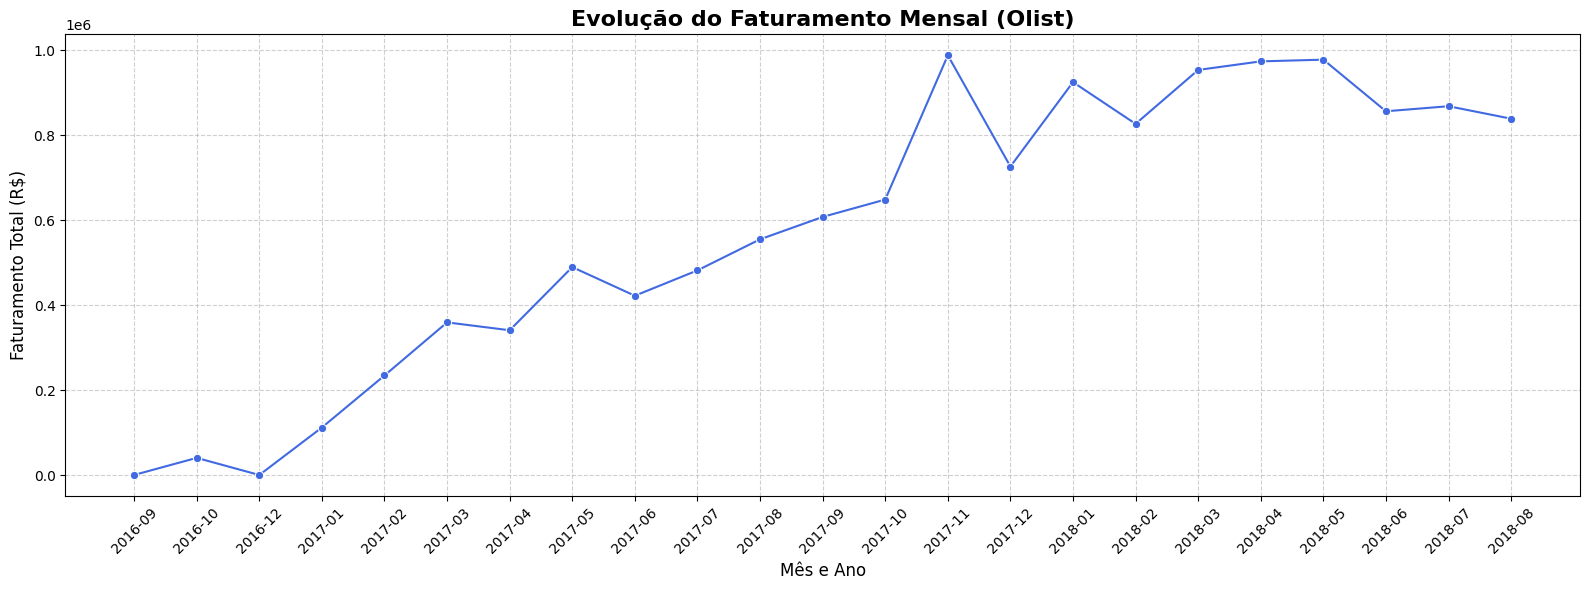

In [31]:
# Configurando o tamanho da figura
plt.figure(figsize=(16, 6))

# Criando o gráfico de linha
sns.lineplot(data=faturamento_mensal, x='mes_ano', y='price', marker='o', color='royalblue')

# Adicionando títulos e rótulos
plt.title('Evolução do Faturamento Mensal (Olist)', fontsize=16, fontweight='bold')
plt.xlabel('Mês e Ano', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)

# Rotacionando as datas no eixo X para facilitar a leitura
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustando o layout para não cortar nada
plt.tight_layout()
plt.show()

### A Sazonalidade do Fim de Ano:
Esse pico em outubro e novembro é o efeito direto do aquecimento para a Black Friday e antecipação de compras de Natal. A queda a partir de maio reflete o esfriamento natural do varejo após o Dia das Mães, um padrão muito clássico no e-commerce.

# Gráfico 2 - Distribuição Geográfica (Top 10 Estados)

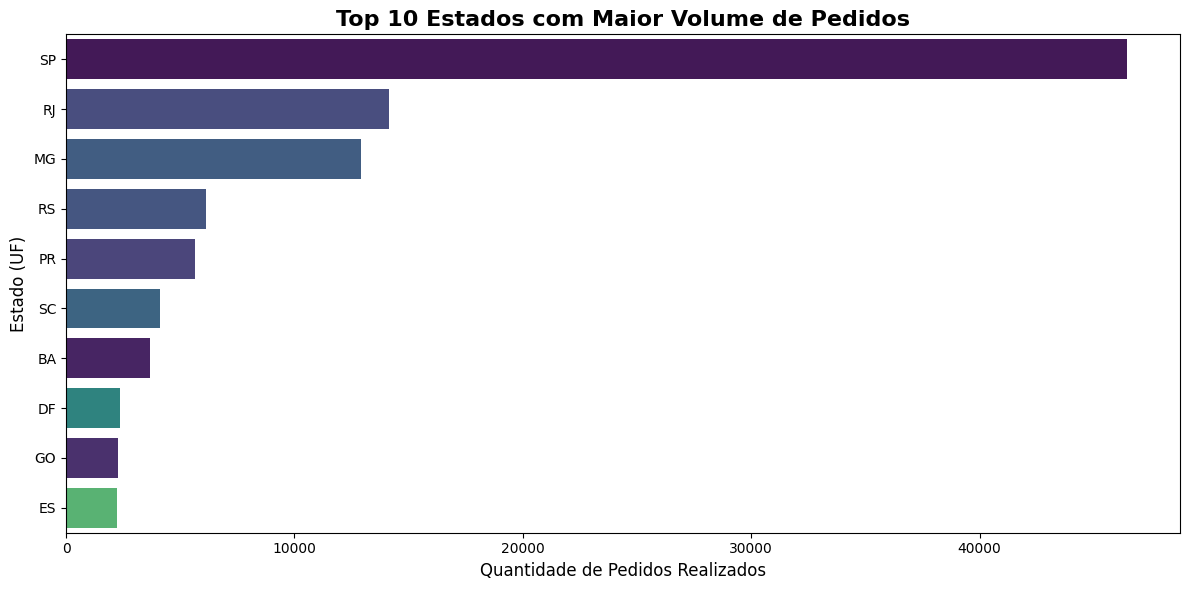

In [32]:
plt.figure(figsize=(12, 6))

# Criando um gráfico de barras horizontais contando o número de clientes por estado
# Usamos value_counts() para pegar os 10 estados com mais ocorrências
sns.countplot(
    data=df_master,
    y='customer_state',
    order=df_master['customer_state'].value_counts().index[:10],
    palette='viridis',
    hue='customer_state',
    legend=False
)

plt.title('Top 10 Estados com Maior Volume de Pedidos', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Pedidos Realizados', fontsize=12)
plt.ylabel('Estado (UF)', fontsize=12)

plt.tight_layout()
plt.show()

### A Hegemonia de São Paulo:
A diferença "gritante" de SP faz total sentido não apenas pela densidade populacional, mas pela infraestrutura logística. A maioria dos centros de distribuição fica no Sudeste (especialmente SP), o que torna o frete mais barato e a entrega mais rápida para quem mora lá, incentivando a conversão de vendas.

In [33]:
# Calculando a diferença em dias entre a entrega e a compra
df_master['tempo_entrega_dias'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days

# Vamos ver a média geral de entrega do e-commerce inteiro
media_geral = df_master['tempo_entrega_dias'].mean()
print(f"O tempo médio geral de entrega no Brasil é de: {media_geral:.1f} dias")

O tempo médio geral de entrega no Brasil é de: 12.0 dias


# Gráfico 3 - Tempo Médio de Entrega por Estado

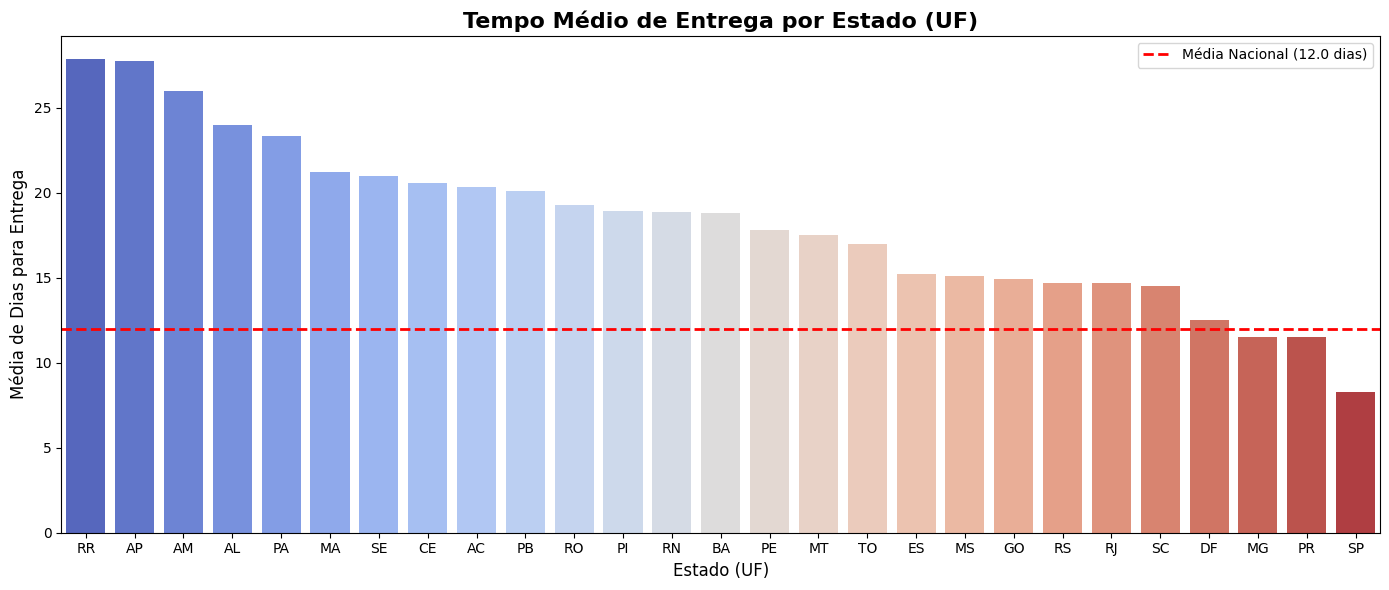

In [34]:
# Agrupando pelo estado e calculando a média de dias de entrega
tempo_medio_estado = df_master.groupby('customer_state')['tempo_entrega_dias'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 6))

# Criando um gráfico de barras. Usamos a paleta 'coolwarm' para destacar os maiores (vermelho) e menores (azul) tempos
sns.barplot(
    data=tempo_medio_estado, 
    x='customer_state', 
    y='tempo_entrega_dias', 
    palette='coolwarm',
    hue='customer_state',
    legend=False
)

# Adicionando uma linha de referência com a média nacional
plt.axhline(media_geral, color='red', linestyle='--', linewidth=2, label=f'Média Nacional ({media_geral:.1f} dias)')

plt.title('Tempo Médio de Entrega por Estado (UF)', fontsize=16, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Média de Dias para Entrega', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

### Análise do Tempo Médio de Entrega por Unidade Federativa no Brasil
A análise do tempo médio de entrega por unidade federativa evidencia diferenças relevantes de desempenho logístico entre os estados brasileiros. Observa-se que São Paulo (SP), apesar de concentrar o maior volume de pedidos do país, apresenta o menor tempo médio de entrega, posicionando-se significativamente abaixo da média nacional (12 dias). Esse resultado sugere elevada eficiência operacional, possivelmente associada a fatores como maior densidade de centros de distribuição, proximidade entre oferta e demanda, infraestrutura de transporte mais desenvolvida e ganhos de escala logísticos.

Adicionalmente, o alto volume de pedidos em SP tende a justificar investimentos mais intensivos em tecnologia, gestão de estoques e otimização de rotas, o que contribui para a redução do lead time logístico. Esse cenário é consistente com modelos de operação em mercados de alta demanda, nos quais a eficiência se torna um diferencial competitivo crítico.

Em contrapartida, estados como Roraima (RR) e Amapá (AP) apresentam os maiores tempos médios de entrega, situando-se bem acima da média nacional. Esse desempenho pode ser explicado por fatores estruturais, como maior distância dos principais centros econômicos e logísticos do país, menor capilaridade da malha de transporte, limitações de infraestrutura e menor densidade de demanda. Esses elementos tendem a aumentar a complexidade operacional e os custos logísticos, impactando negativamente os prazos de entrega.

De forma geral, os dados indicam uma correlação entre eficiência logística, localização geográfica e escala de demanda. Estados mais centrais e economicamente dinâmicos apresentam melhor desempenho logístico, enquanto regiões periféricas enfrentam desafios estruturais que resultam em maiores tempos de entrega.